# Notebook to analyze the results for the case study MAR MHD dataset
21-05-2026

In [1]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./results/mar_mhd_all_results_2105.csv")
print(len(df))

# Preprocessing on the data 

## Change the datasets keys to "Complete" and "Incomplete"
incomplete_data_key = df.datasets.unique()[0]
complete_data_key = df.datasets.unique()[1]
df = df.replace(incomplete_data_key, "Incomplete")
df = df.replace(complete_data_key, "Complete")

## Change the model names to be more readable
df =  df.replace(
    {m : m[:-6] for m in np.unique(df['model_config.name'].values)})
df = df.replace('MMVAEPlus','MMVAE+')

## Rename the columns
df = df.rename(columns={
    "model_config.name":"Model",
    "datasets": "Dataset",
    "keep_incomplete": "Keep incomplete"
    })

df.columns

60


Index(['Name', 'Model', 'Keep incomplete', 'model_config.learn_modality_prior',
       'Dataset', 'ID', 'MFD_label_0', 'MFD_label_1', 'MFD_label_2',
       'MFD_label_3', 'MFD_label_4', 'MFD_label_5', 'MFD_label_6',
       'MFD_label_7', 'MFD_label_8', 'MFD_label_9',
       '['audio'] reconstruction error (MSE)',
       '['audio'] reconstruction error (SSIM)',
       '['image'] reconstruction error (MSE)',
       '['image'] reconstruction error (SSIM)', 'mean_coherence_1',
       'mean_coherence_1_class_0', 'mean_coherence_1_class_1',
       'mean_coherence_1_class_2', 'mean_coherence_1_class_3',
       'mean_coherence_1_class_4', 'mean_coherence_1_class_5',
       'mean_coherence_1_class_6', 'mean_coherence_1_class_7',
       'mean_coherence_1_class_8', 'mean_coherence_1_class_9',
       'mean_coherence_2', 'mean_coherence_2_class_0',
       'mean_coherence_2_class_1', 'mean_coherence_2_class_2',
       'mean_coherence_2_class_3', 'mean_coherence_2_class_4',
       'mean_coherence_2_c

## Coherences

In [3]:
# Melt the coherences in df

df_coherences = df.melt(id_vars=["Model", "Dataset","Keep incomplete"], value_vars=["mean_coherence_1", "mean_coherence_2", "joint_coherence_prior"], value_name="Coherence", var_name="Number of input modalities")

df_coherences = df_coherences.replace({
    "mean_coherence_1": 1,
    "mean_coherence_2": 2,
    "joint_coherence_prior": 0
})

df_coherences

,Model,Dataset,Keep incomplete,Number of input modalities,Coherence
0,MVAE,Incomplete,True,1,0.507833
1,MVAE,Incomplete,True,1,0.527733
2,MVAE,Incomplete,True,1,0.514633
3,MVAE,Incomplete,True,1,0.528150
4,MVTCAE,Incomplete,True,1,0.786150
...,...,...,...,...,...
175,MoPoE,Incomplete,False,0,0.401400
176,MVTCAE,Incomplete,False,0,0.246100
177,MVTCAE,Incomplete,False,0,0.248300
178,MVTCAE,Incomplete,False,0,0.248500


/Users/agathe/dev/multivae_package/venv/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


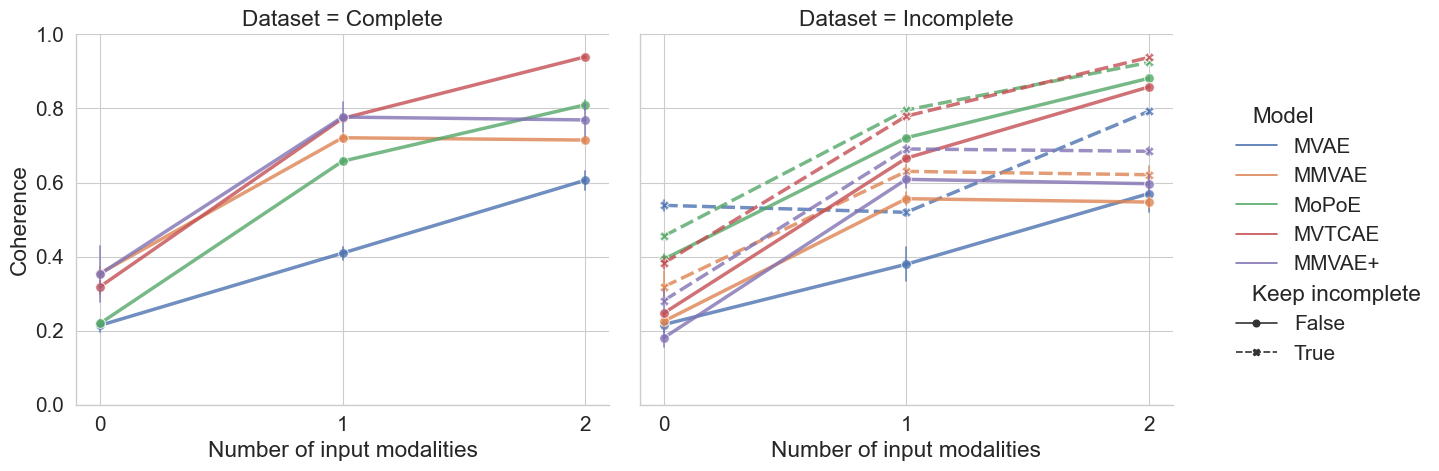

In [4]:
from matplotlib.patches import Patch
sb.set_theme(style="whitegrid")
sb.set_context('paper', font_scale=1.7)

g = sb.relplot(
    data=df_coherences,
    x='Number of input modalities',
    y='Coherence',
    col='Dataset',
    style='Keep incomplete',
    hue='Model',
    kind='line',
    errorbar = 'sd',
    err_style = 'bars', 
    alpha = 0.8,
    markers=True,
    linewidth=2.5,
    hue_order=['MVAE', 'MMVAE','MoPoE','MVTCAE','MMVAE+'],
    col_order=['Complete', 'Incomplete'],
    markersize=7,
    # legend=False
)

# set ticks [0,1,2]
for ax in g.axes.flat:
    ax.set_xticks([0,1,2])
    ax.set_ylim(0,1)
    
# Add a custom legend
# legend_elements = [
#     Patch(facecolor=sb.color_palette()[0], label='MVAE'),
#     Patch(facecolor=sb.color_palette()[1], label='MMVAE'),
#     Patch(facecolor=sb.color_palette()[2], label='MoPoE'),
#     Patch(facecolor=sb.color_palette()[3], label='MVTCAE'),
#     Patch(facecolor=sb.color_palette()[4], label='MMVAE+')
# ]
# g.axes[0,1].legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(1.3, 1), ncol=1)
    
fig = g.figure
fig.set_size_inches(15, 5)

plt.savefig("/Users/agathe/Documents/thèse/manuscript/phd_manuscript/figures/multivae_library/mhd_coherences.pdf", bbox_inches='tight')


# MFD

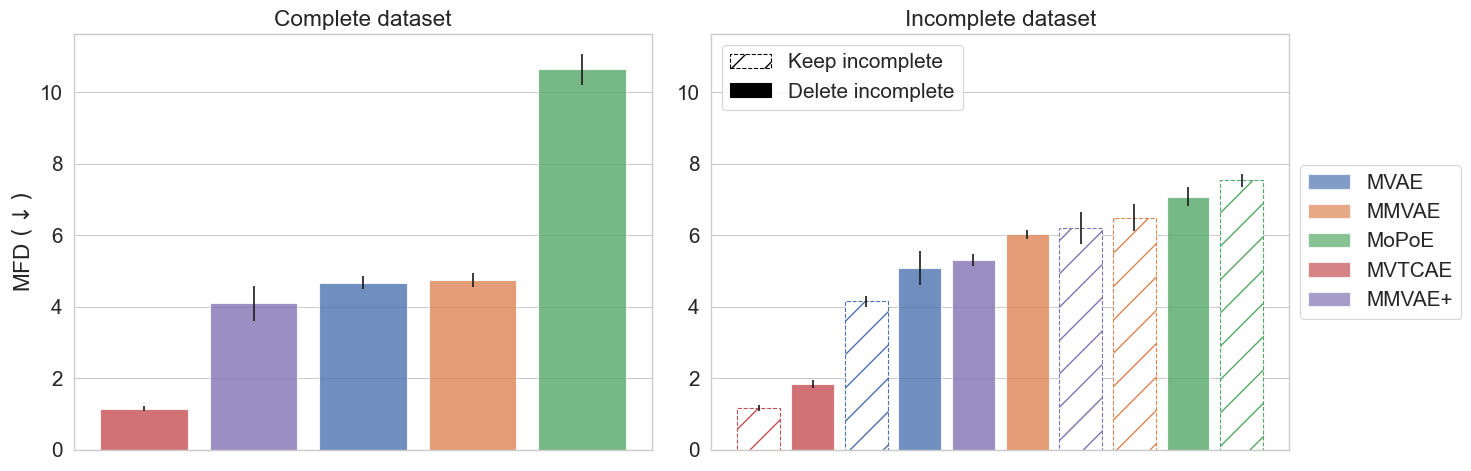

In [5]:
df['MFD'] = 0
for i in range(10):
    df['MFD'] += df['MFD_label_'+str(i)]
df['MFD'] = df['MFD'] / 10

df = df.sort_values(by=['MFD'])

# Create a barplot where the color of the bar is the same as in the lineplot above
color_mapping = {
                'MVAE': sb.color_palette()[0],
                'MMVAE': sb.color_palette()[1],
                'MoPoE': sb.color_palette()[2],
                'MVTCAE': sb.color_palette()[3],
                'MMVAE+': sb.color_palette()[4]
                                           }

alpha=0.8

plt.figure(figsize=(15,5))
ax1 = plt.subplot(1,2,1)
# plot the bars for the complete dataset
values = df[df['Dataset'] == 'Complete'].groupby('Model')['MFD'].mean()
std = df[df['Dataset'] == 'Complete'].groupby('Model')['MFD'].std()
order = np.argsort(values)
colors = [color_mapping[values.index[i]] for i in order]
plt.bar(np.arange(len(order)),values[order],yerr=std[order],color=colors,alpha=alpha)
plt.ylabel(r'MFD $(\downarrow)$')
plt.xticks([])
plt.title('Complete dataset')

ax2 = plt.subplot(1,2,2,sharey=ax1)
values = df[df['Dataset'] == 'Incomplete'].groupby(['Model','Keep incomplete']).MFD.mean()
std = df[df['Dataset'] == 'Incomplete'].groupby(['Model','Keep incomplete']).MFD.std()
order = np.argsort(values)
colors = [color_mapping[values.index[i][0]] for i in order]

keep_incomplete = np.array([values.index[i][1] for i in order],dtype=bool)

plt.bar(np.arange(len(order))[keep_incomplete],
        np.array(values)[order][keep_incomplete],
        yerr=np.array(std)[order][keep_incomplete],
        edgecolor=np.array(colors)[keep_incomplete],
        facecolor='white',
        linestyle='--',
        hatch='/'
        )
plt.bar(np.arange(len(order))[~keep_incomplete],
        np.array(values)[order][~keep_incomplete],
        yerr=np.array(std)[order][~keep_incomplete],
        color=np.array(colors)[~keep_incomplete],
        alpha=alpha
       
        )
plt.xticks([])

plt.title('Incomplete dataset')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='white', edgecolor='black', linestyle='--', hatch='/', label='Keep incomplete'),
                   Patch(facecolor='black', edgecolor='black', label='Delete incomplete')]
legend_incomplete = plt.legend(handles=legend_elements, loc='upper left')

# Add colors to the legend
for i, model in enumerate(['MVAE', 'MMVAE','MoPoE','MVTCAE','MMVAE+']):
    plt.bar(0, 0, color=color_mapping[model], label=model, alpha=0.7)
    
# put the legend outside the plot on the right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.add_artist(legend_incomplete)

plt.tight_layout()
plt.savefig("/Users/agathe/Documents/thèse/manuscript/phd_manuscript/figures/multivae_library/mhd_mfd.pdf", bbox_inches='tight')

# Detailed coherences plot

Objectif: regarder le biais lorsque l'on choisit de garder les samples incomplets versus quand on les enlève.

In [6]:
# Melt the mean_coherence_1

df2 = df.melt(id_vars=["Model", "Dataset","Keep incomplete"], 
              value_vars=[f"mean_coherence_1_class_{i}" for i in range(10)], 
              value_name="Coherence", 
              var_name="Label")
df2 = df2.replace({f"mean_coherence_1_class_{i}": i for i in range(10)})

/Users/agathe/dev/multivae_package/venv/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/hr/qpjfsj3j5xb5275fpjrz4_n80000gq/T/ipykernel_77248/1775048389.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


[ 6. 20.]


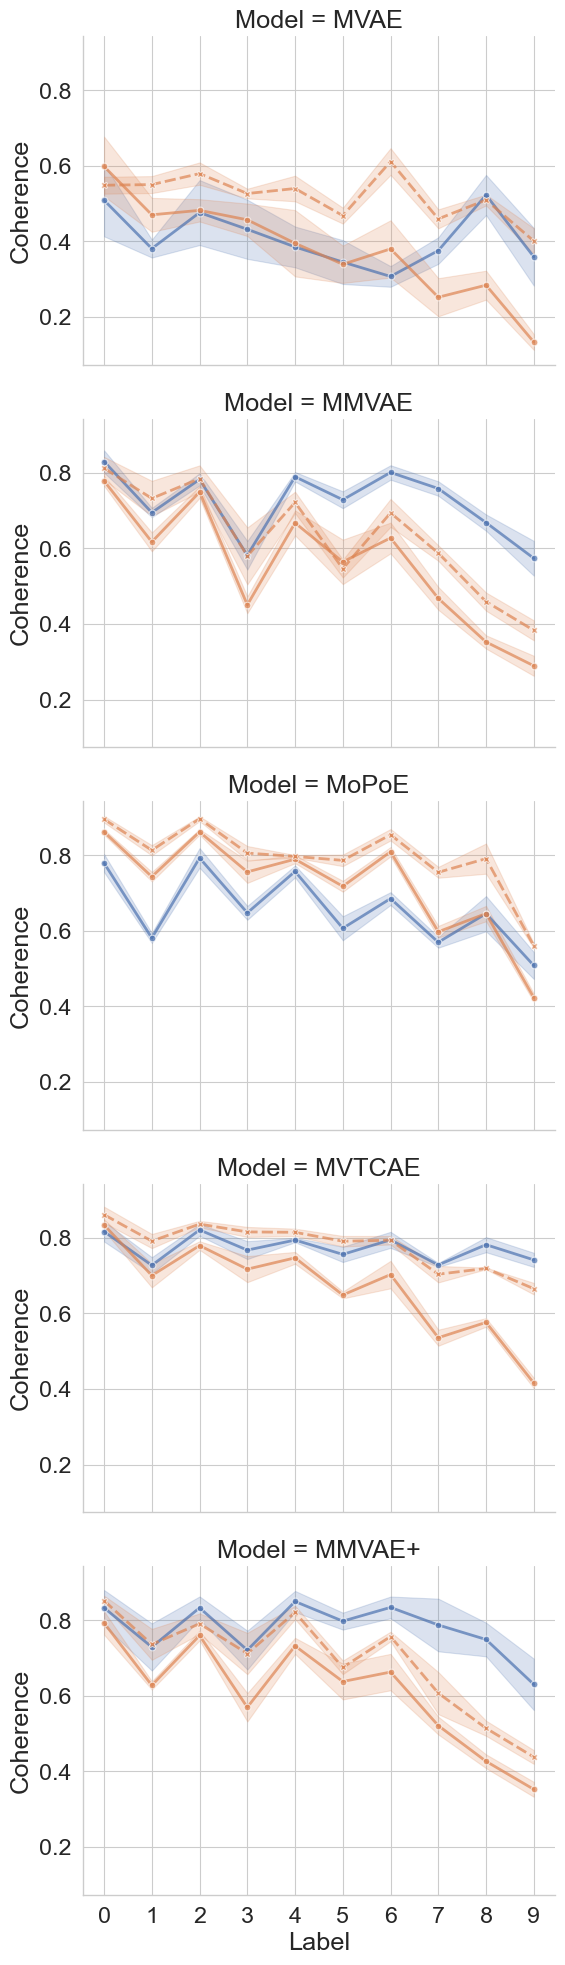

In [7]:
sb.set_context('paper', font_scale=1.9)
g = sb.relplot(
    data = df2,
    x = 'Label',
    y = 'Coherence',
    col = 'Model',
    hue='Dataset',
    kind = 'line',
    style='Keep incomplete',
    errorbar = 'sd',
    # err_style = 'bars',
    alpha = 0.7,
    markers = True,
    linewidth = 2,
    aspect=1.5,
    col_wrap=1,
    col_order=['MVAE', 'MMVAE','MoPoE','MVTCAE','MMVAE+'],
    hue_order=['Complete', 'Incomplete'],
    legend=False,
    height=4,
    
)
# set x_ticks on all subplots
for ax in g.axes.flat:
    ax.set_xticks([0,1,2,3,4,5,6,7,8,9])
    
plt.tight_layout()
    
# print size of the figure
fig = g.figure
print(fig.get_size_inches())


plt.savefig("/Users/agathe/Documents/thèse/manuscript/phd_manuscript/figures/multivae_library/mhd_coherences_per_class.pdf", bbox_inches='tight')

# Mean Fréchet Distance



In [8]:
df3 = df.melt(id_vars=["Model", "Dataset","Keep incomplete"], 
              value_vars=[f"MFD_label_{i}" for i in range(10)], 
              value_name=r"MFD $(\downarrow)$ per label", 
              var_name="Label")
df3 = df3.replace({f"MFD_label_{i}": i for i in range(10)})

/Users/agathe/dev/multivae_package/venv/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


[ 8.26155556 20.        ]


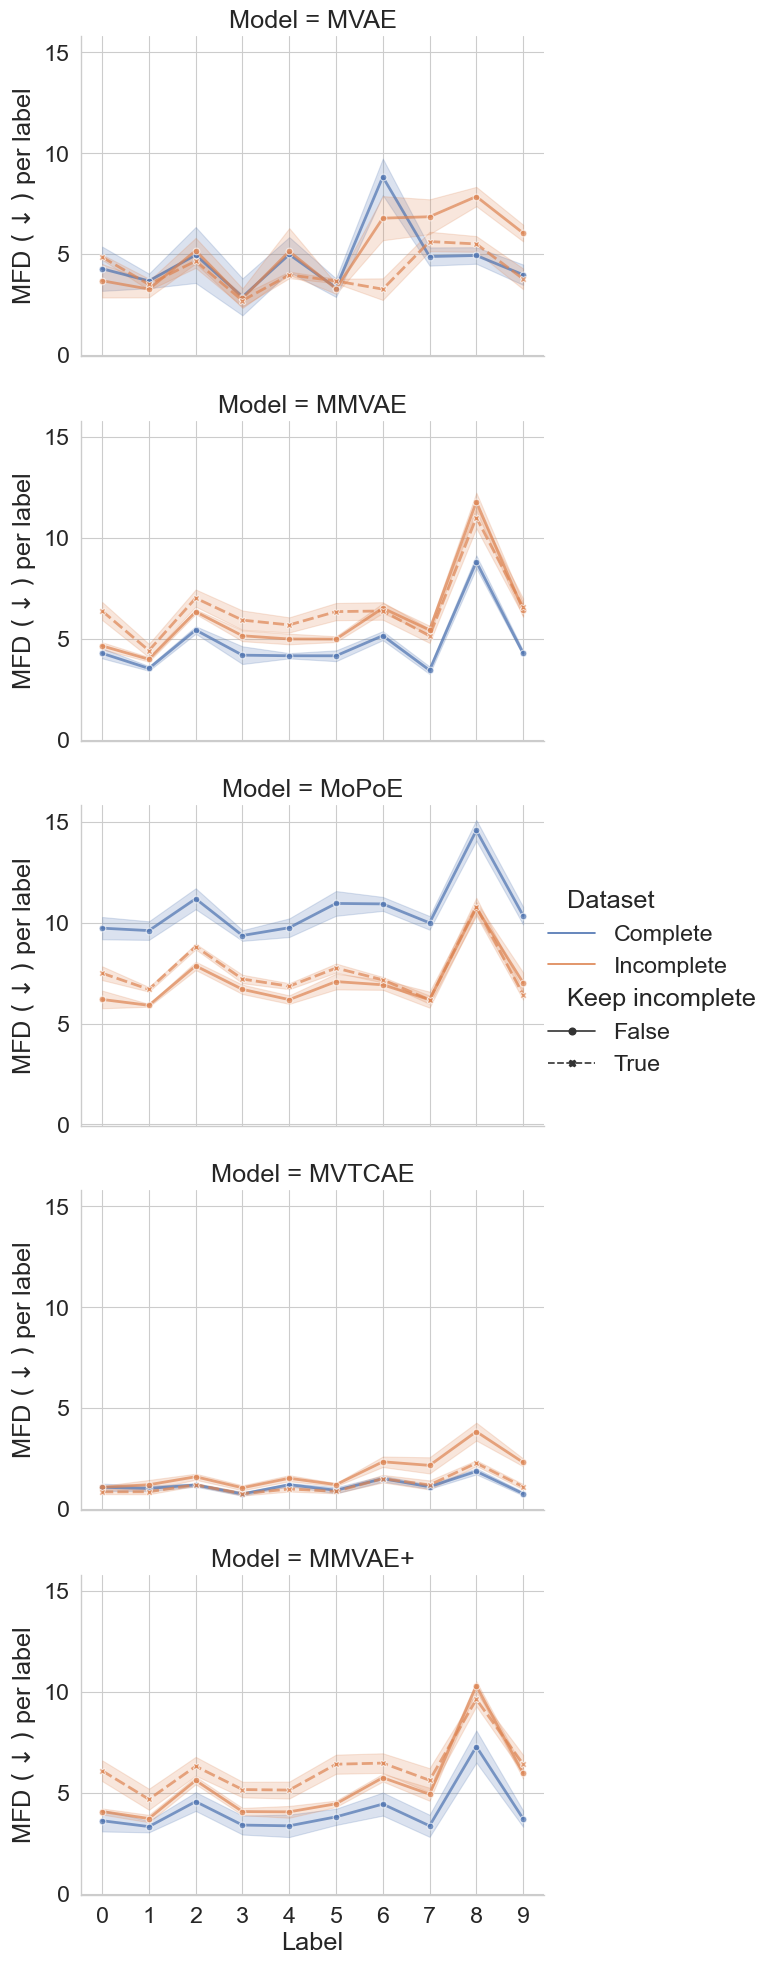

In [9]:
sb.set_context('paper', font_scale=1.9)

g = sb.relplot(
    data = df3,
    x = 'Label',
    y = r"MFD $(\downarrow)$ per label",
    col = 'Model',
    hue='Dataset',
    kind = 'line',
    style='Keep incomplete',
    errorbar = 'sd',
    # err_style = 'bars',
    alpha = 0.7,
    markers = True,
    linewidth = 2,
    aspect=1.5,
    col_wrap=1,
    col_order=['MVAE', 'MMVAE','MoPoE','MVTCAE','MMVAE+'],
    hue_order=['Complete', 'Incomplete'],
    height=4,
    
)
# set x_ticks on all subplots
for ax in g.axes.flat:
    ax.set_xticks([0,1,2,3,4,5,6,7,8,9])
    
# plt.tight_layout() 

# print size of the figure
fig = g.figure
print(fig.get_size_inches())
    

plt.savefig("/Users/agathe/Documents/thèse/manuscript/phd_manuscript/figures/multivae_library/mhd_mfd_per_class.pdf", bbox_inches='tight')

# Qualité de reconstruction 

<Axes: xlabel='Model', ylabel='Audio Reconstruction MSE'>

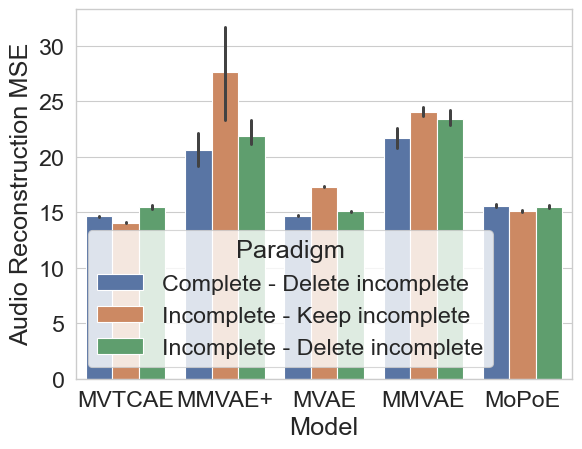

In [10]:
df = df.rename(columns={
    "['image'] reconstruction error (MSE)": "Image Reconstruction MSE",
    "['audio'] reconstruction error (MSE)": "Audio Reconstruction MSE",
})

df['Paradigm'] = df['Dataset'] + ' - ' + df['Keep incomplete'].apply(lambda x: 'Keep incomplete' if x else 'Delete incomplete')
sb.barplot(
    df,
    hue='Paradigm',
    x='Model',
    y='Audio Reconstruction MSE',
)

